# JARVIS - Analitica de Spotify con IA

**Curso:** Modelos de Computacion  
**Enfoque:** AED + Clasificacion + NLP + OpenAI  
**Dataset:** spotify_2015_2025_85k.csv

---

Este cuaderno esta centrado en un dataset de Spotify. Incluye analisis exploratorio de datos (AED), modelos de clasificacion, procesamiento de lenguaje natural y asistencia con OpenAI para generar resumenes y responder preguntas en lenguaje natural.


## 1. Preparacion del entorno (Google Colab y local)


In [34]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn openai python-dotenv


## 2. Importaciones y configuracion


In [35]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

from dotenv import load_dotenv
from openai import OpenAI
import openai

warnings.filterwarnings("ignore")

# Estilo con buenas practicas de matplotlib (skill)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
pd.set_option("display.max_columns", 120)

print("Entorno listo")


Entorno listo


## 3. (Opcional) Montar Google Drive

Descomenta esta celda si quieres leer el CSV desde tu Drive en Colab.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


## 4. Carga robusta del dataset


In [36]:
rutas_candidatas = [
    Path('/content/spotify_2015_2025_85k.csv'),
    Path('/content/data/spotify_2015_2025_85k.csv'),
    Path('/content/drive/MyDrive/spotify_2015_2025_85k.csv'),
    Path('/content/drive/MyDrive/data/spotify_2015_2025_85k.csv'),
    Path('spotify_2015_2025_85k.csv'),
    Path('data/spotify_2015_2025_85k.csv'),
    Path('../data/spotify_2015_2025_85k.csv'),
]

ruta_csv = next((p for p in rutas_candidatas if p.exists()), None)
if ruta_csv is None:
    raise FileNotFoundError('No se encontro spotify_2015_2025_85k.csv. Sube el archivo a Colab o ajusta rutas_candidatas.')

df = pd.read_csv(ruta_csv)
print(f'CSV cargado desde: {ruta_csv}')
print(f'Dimensiones iniciales: {df.shape}')
df.head()


CSV cargado desde: ..\data\spotify_2015_2025_85k.csv
Dimensiones iniciales: (85000, 19)


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent


## 5. Exploracion inicial y calidad de datos


In [37]:
print('Columnas del dataset:')
print(df.columns.tolist())

print('Tipos de datos:')
print(df.dtypes)

print('Resumen de memoria (deep):')
df.info(memory_usage='deep')


Columnas del dataset:
['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label']
Tipos de datos:
track_id                str
track_name              str
artist_name             str
album_name              str
release_date            str
genre                   str
duration_ms           int64
popularity            int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
instrumentalness    float64
tempo               float64
stream_count          int64
country                 str
explicit              int64
label                   str
dtype: object
Resumen de memoria (deep):
<class 'pandas.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
--- 

In [38]:
nulos = df.isna().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(3)
perfil_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct})
perfil_nulos.head(20)


,nulos,porcentaje
album_name,46,0.054
track_name,21,0.025
track_id,0,0.000
artist_name,0,0.000
release_date,0,0.000
genre,0,0.000
duration_ms,0,0.000
popularity,0,0.000
danceability,0,0.000
energy,0,0.000


## 6. Limpieza y transformacion


In [39]:
df_limpio = df.copy()

# Normalizacion de texto
for col in ['genre', 'country', 'label', 'artist_name', 'track_name', 'album_name']:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].astype('string').str.strip()

mapa_genero_es = {
    'Pop': 'Pop',
    'Rock': 'Rock',
    'Hip-Hop': 'Hip-Hop',
    'R&B': 'R y B',
    'EDM': 'Electronica (EDM)',
    'Jazz': 'Jazz',
    'Classical': 'Clasica',
    'Country': 'Country',
    'Indie': 'Indie',
    'Metal': 'Metal',
    'Folk': 'Folk',
    'Reggaeton': 'Regueton',
}

df_limpio['genero_es'] = df_limpio['genre'].map(mapa_genero_es).fillna(df_limpio['genre'])
df_limpio['explicita_es'] = df_limpio['explicit'].astype(int).map({0: 'No explicita', 1: 'Explicita'})

# Conversion de fechas
df_limpio['release_date'] = pd.to_datetime(df_limpio['release_date'], errors='coerce')
df_limpio['release_year'] = df_limpio['release_date'].dt.year
df_limpio['release_month'] = df_limpio['release_date'].dt.month

# Eliminar duplicados por track_id
antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates(subset=['track_id']).reset_index(drop=True)
print(f'Duplicados eliminados por track_id: {antes - len(df_limpio)}')

# Tipos categoricos de baja y media cardinalidad
for col in ['genre', 'genero_es', 'country', 'label', 'explicita_es', 'explicit', 'mode', 'key']:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].astype('category')

print('Dimensiones despues de limpieza:', df_limpio.shape)
df_limpio.head()


Duplicados eliminados por track_id: 0
Dimensiones despues de limpieza: (85000, 23)


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,genero_es,explicita_es,release_year,release_month
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music,Pop,No explicita,2016,4
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records,Metal,Explicita,2022,4
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings,Rock,Explicita,2016,2
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music,Pop,No explicita,2015,10
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent,Indie,No explicita,2022,7


## 7. AED - Resumen general


In [40]:
resumen = {
    'registros': int(df_limpio.shape[0]),
    'columnas': int(df_limpio.shape[1]),
    'generos_unicos': int(df_limpio['genero_es'].nunique()),
    'paises_unicos': int(df_limpio['country'].nunique()),
    'labels_unicos': int(df_limpio['label'].nunique()),
    'popularidad_promedio': float(df_limpio['popularity'].mean()),
    'streams_promedio': float(df_limpio['stream_count'].mean()),
}
resumen


{'registros': 85000,
 'columnas': 23,
 'generos_unicos': 12,
 'paises_unicos': 10,
 'labels_unicos': 8,
 'popularidad_promedio': 48.162894117647056,
 'streams_promedio': 214354.68235294116}

## 8. Visualizaciones principales (Matplotlib OO API)


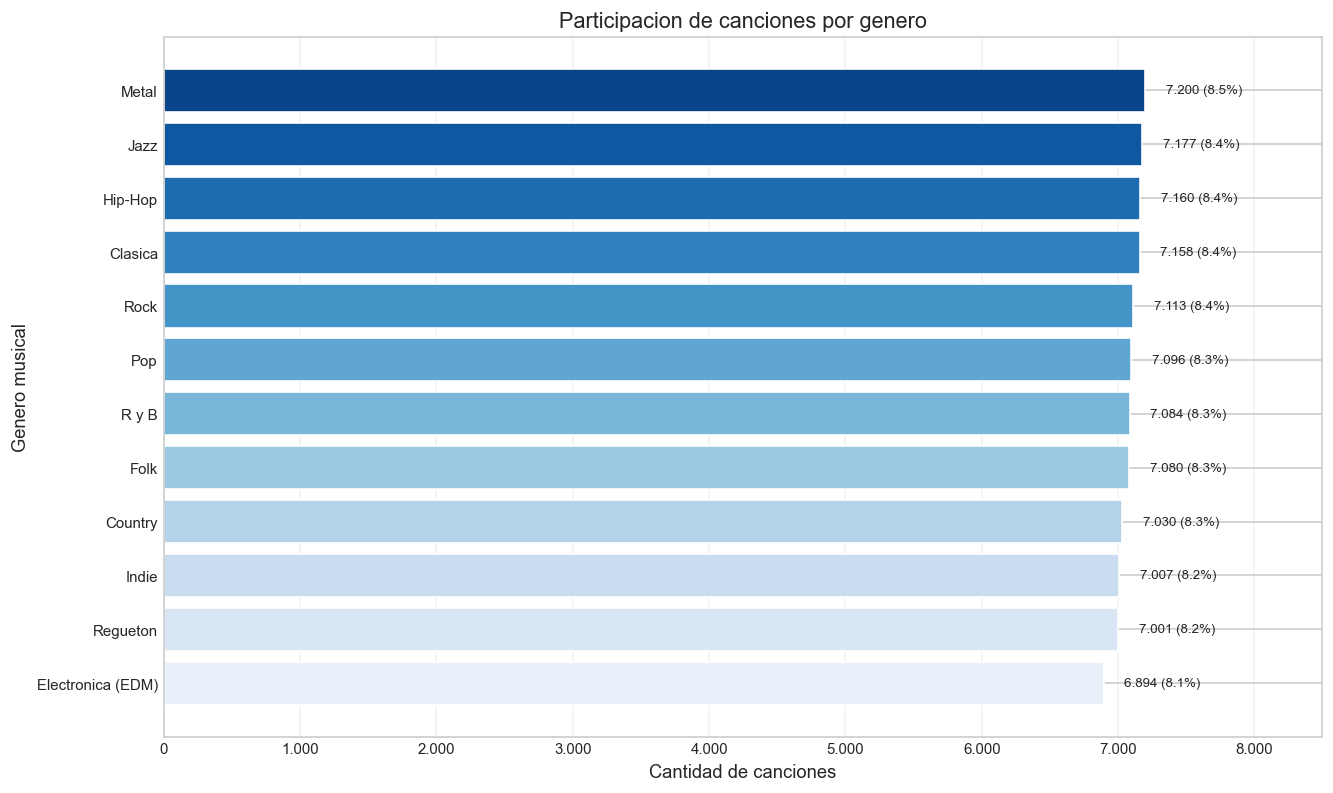

In [41]:
# Participacion por genero (ordenado y legible para exposicion)
conteo_genero = df_limpio['genero_es'].value_counts().sort_values(ascending=True)
total_canciones = conteo_genero.sum()
porc_genero = (conteo_genero / total_canciones * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 6.5), constrained_layout=True)
palette = sns.color_palette('Blues', n_colors=len(conteo_genero))
bars = ax.barh(conteo_genero.index, conteo_genero.values, color=palette)

ax.set_title('Participacion de canciones por genero')
ax.set_xlabel('Cantidad de canciones')
ax.set_ylabel('Genero musical')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', '.')))
ax.set_xlim(0, conteo_genero.max() * 1.18)
ax.grid(axis='x', alpha=0.25)

for bar, valor, porc in zip(bars, conteo_genero.values, porc_genero.values):
    etiqueta = f"{valor:,}".replace(',', '.') + f" ({porc}%)"
    ax.text(valor + total_canciones * 0.0018, bar.get_y() + bar.get_height() / 2, etiqueta, va='center', fontsize=8)

plt.show()


,anio,canciones,variacion_%_vs_anio_anterior
5,2020,7800,1.62
6,2021,7468,-4.26
7,2022,7733,3.55
8,2023,7801,0.88
9,2024,7698,-1.32
10,2025,7712,0.18


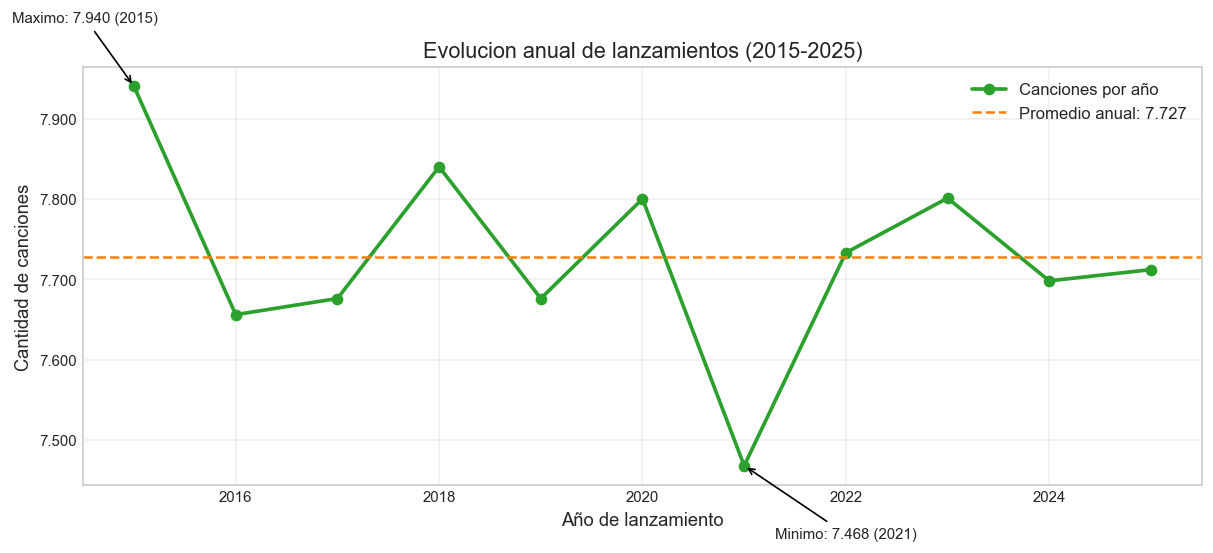

In [43]:
# Evolucion por anio de lanzamiento con puntos clave
serie_anual = df_limpio.groupby('release_year').size().sort_index()
variacion_anual = (serie_anual.pct_change() * 100).round(2)
promedio_anual = serie_anual.mean()
anio_max = int(serie_anual.idxmax())
anio_min = int(serie_anual.idxmin())

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
ax.plot(serie_anual.index, serie_anual.values, marker='o', linewidth=2.2, color='tab:green', label='Canciones por año')
ax.axhline(promedio_anual, color='tab:orange', linestyle='--', linewidth=1.5, label=f'Promedio anual: {promedio_anual:,.0f}'.replace(',', '.'))
ax.set_title('Evolucion anual de lanzamientos (2015-2025)')
ax.set_xlabel('Año de lanzamiento')
ax.set_ylabel('Cantidad de canciones')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}".replace(',', '.')))
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

ax.annotate(
    f"Maximo: {serie_anual[anio_max]:,}".replace(',', '.') + f" ({anio_max})",
    xy=(anio_max, serie_anual[anio_max]),
    xytext=(anio_max - 1.2, serie_anual[anio_max] + 80),
    arrowprops={'arrowstyle': '->', 'color': 'black', 'lw': 1},
    fontsize=9,
)
ax.annotate(
    f"Minimo: {serie_anual[anio_min]:,}".replace(',', '.') + f" ({anio_min})",
    xy=(anio_min, serie_anual[anio_min]),
    xytext=(anio_min + 0.3, serie_anual[anio_min] - 90),
    arrowprops={'arrowstyle': '->', 'color': 'black', 'lw': 1},
    fontsize=9,
)

display(
    pd.DataFrame({
        'anio': serie_anual.index,
        'canciones': serie_anual.values,
        'variacion_%_vs_anio_anterior': variacion_anual.values,
    }).tail(6)
)

plt.show()


,mediana,promedio,desv_estandar,minimo,maximo
genero_es,,,,,
Clasica,47.0,48.36,14.83,8,100
Folk,47.0,48.10,14.97,6,100
R y B,47.0,48.36,15.20,4,100
Hip-Hop,47.0,48.36,15.09,2,100
Indie,47.0,48.12,14.58,5,100
Metal,47.0,48.19,14.75,0,100
Pop,47.0,48.37,15.00,7,100
Country,46.0,48.17,14.85,6,100
Jazz,46.0,47.85,14.64,6,100


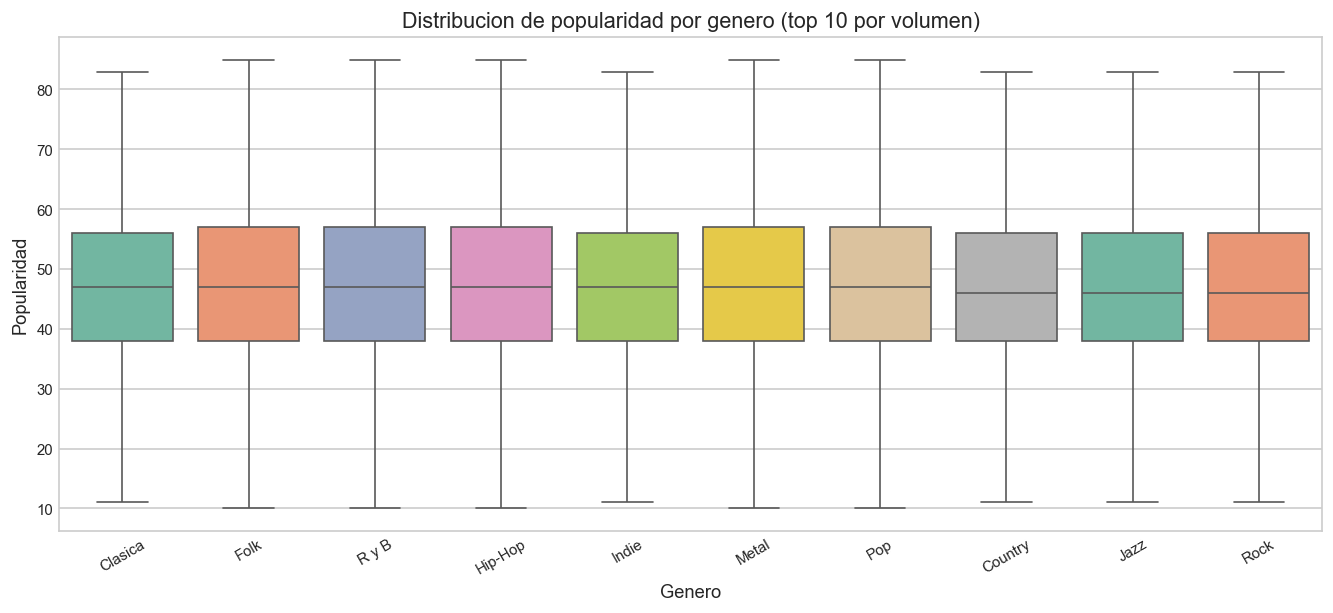

In [44]:
# Popularidad por genero (ordenado por mediana)
top10 = df_limpio['genero_es'].value_counts().head(10).index
df_top10 = df_limpio[df_limpio['genero_es'].isin(top10)].copy()
orden_mediana = (
    df_top10.groupby('genero_es')['popularity']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
sns.boxplot(
    data=df_top10,
    x='genero_es',
    y='popularity',
    order=orden_mediana,
    ax=ax,
    palette='Set2',
    showfliers=False,
)
ax.set_title('Distribucion de popularidad por genero (top 10 por volumen)')
ax.set_xlabel('Genero')
ax.set_ylabel('Popularidad')
ax.tick_params(axis='x', rotation=30)

resumen_pop = (
    df_top10.groupby('genero_es')['popularity']
    .agg(['median', 'mean', 'std', 'min', 'max'])
    .rename(columns={
        'median': 'mediana',
        'mean': 'promedio',
        'std': 'desv_estandar',
        'min': 'minimo',
        'max': 'maximo',
    })
    .round(2)
    .sort_values(by='mediana', ascending=False)
)
display(resumen_pop)

plt.show()


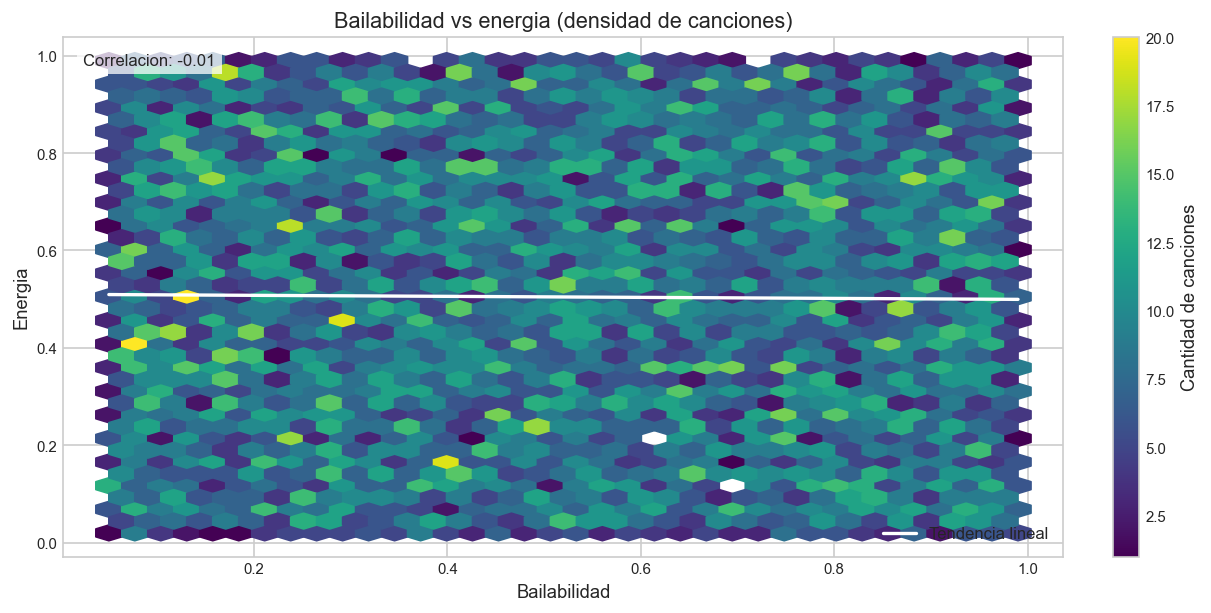

In [45]:
# Relacion bailabilidad vs energia (densidad + tendencia)
sample_scatter = df_limpio.sample(n=min(12000, len(df_limpio)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
hb = ax.hexbin(
    sample_scatter['danceability'],
    sample_scatter['energy'],
    cmap='viridis',
    gridsize=35,
    mincnt=1,
)
ax.set_title('Bailabilidad vs energia (densidad de canciones)')
ax.set_xlabel('Bailabilidad')
ax.set_ylabel('Energia')
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('Cantidad de canciones')

# Tendencia lineal para apoyar explicacion verbal
x = sample_scatter['danceability'].to_numpy()
y = sample_scatter['energy'].to_numpy()
coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = coef[0] * x_line + coef[1]
ax.plot(x_line, y_line, color='white', linewidth=2.0, label='Tendencia lineal')

corr_xy = np.corrcoef(x, y)[0, 1]
ax.text(
    0.02,
    0.97,
    f"Correlacion: {corr_xy:.2f}",
    transform=ax.transAxes,
    va='top',
    fontsize=10,
    bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
)
ax.legend(loc='lower right')

plt.show()


Top 6 correlaciones (valor absoluto):


,variable_1,variable_2,correlacion
0,popularidad,reproducciones,0.358
1,energia,tempo,-0.007
2,energia,sonoridad,0.005
3,duracion_ms,bailabilidad,-0.005
4,modo,explicita,-0.004
5,bailabilidad,instrumentalidad,0.004


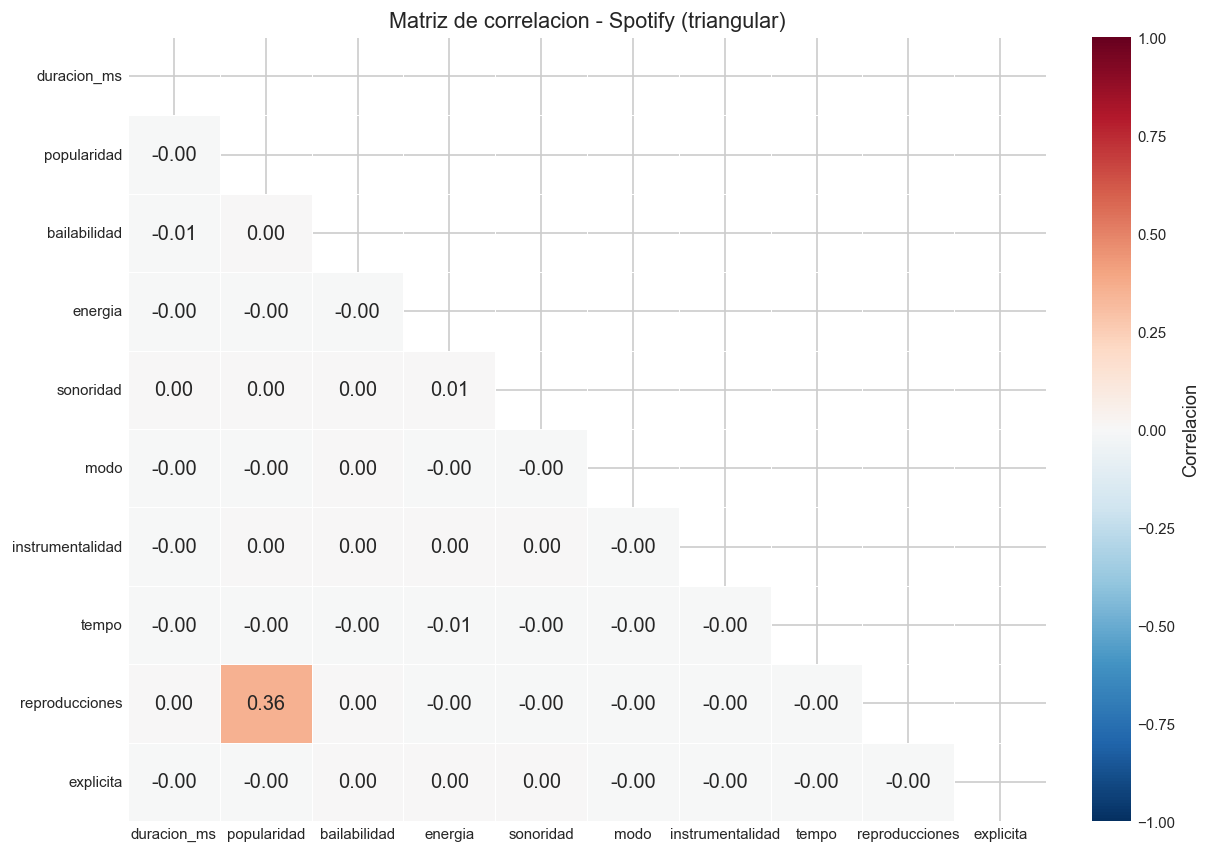

In [46]:
# Correlacion de variables numericas
cols_num = [
    'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'instrumentalness', 'tempo', 'stream_count', 'explicit'
]
num_df = df_limpio[cols_num].copy()
num_df['explicit'] = num_df['explicit'].astype(int)
num_df['mode'] = num_df['mode'].astype(int)

corr = num_df.corr(numeric_only=True)
traduccion_vars = {
    'duration_ms': 'duracion_ms',
    'popularity': 'popularidad',
    'danceability': 'bailabilidad',
    'energy': 'energia',
    'key': 'tonalidad',
    'loudness': 'sonoridad',
    'mode': 'modo',
    'instrumentalness': 'instrumentalidad',
    'tempo': 'tempo',
    'stream_count': 'reproducciones',
    'explicit': 'explicita',
}

corr_es = corr.rename(index=traduccion_vars, columns=traduccion_vars)
mask = np.triu(np.ones_like(corr_es, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
sns.heatmap(
    corr_es,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    cbar_kws={'label': 'Correlacion'},
    ax=ax,
)
ax.set_title('Matriz de correlacion - Spotify (triangular)')

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(6)
)

tabla_corr = pairs.reset_index()
tabla_corr.columns = ['variable_1', 'variable_2', 'correlacion']
tabla_corr['variable_1'] = tabla_corr['variable_1'].map(traduccion_vars)
tabla_corr['variable_2'] = tabla_corr['variable_2'].map(traduccion_vars)
tabla_corr['correlacion'] = tabla_corr['correlacion'].round(3)
print('Top 6 correlaciones (valor absoluto):')
display(tabla_corr)

plt.show()


## 9. Modelo de clasificacion tabular (objetivo: genre)


In [47]:
target = 'genero_es'

df_modelo = df_limpio.copy()
df_modelo = df_modelo[df_modelo[target].notna()].copy()

# Reducir cardinalidad para estabilidad del modelo
conteo_gen = df_modelo[target].astype(str).value_counts()
generos_validos = conteo_gen[conteo_gen >= 30].index
df_modelo = df_modelo[df_modelo[target].astype(str).isin(generos_validos)].copy()

# Feature engineering temporal
df_modelo['release_year'] = pd.to_datetime(df_modelo['release_date'], errors='coerce').dt.year
df_modelo['release_month'] = pd.to_datetime(df_modelo['release_date'], errors='coerce').dt.month

cols_excluir = {'track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'genero_es'}
X = df_modelo[[c for c in df_modelo.columns if c not in cols_excluir]].copy()
y = df_modelo[target].astype(str)

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pre_num = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

pre_cat = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', pre_num, num_cols),
        ('cat', pre_cat, cat_cols),
    ]
)

modelo_logreg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1200)),
])

modelo_rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)),
])

print(f'Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}')
print('Generos incluidos:', sorted(y.unique().tolist()))


Entrenamiento: (68000, 16) | Prueba: (17000, 16)
Generos incluidos: ['Clasica', 'Country', 'Electronica (EDM)', 'Folk', 'Hip-Hop', 'Indie', 'Jazz', 'Metal', 'Pop', 'R y B', 'Regueton', 'Rock']


In [48]:
resultados = []

for nombre, modelo in [('LogisticRegression', modelo_logreg), ('RandomForest', modelo_rf)]:
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro')
    cv = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1).mean()
    resultados.append({'modelo': nombre, 'accuracy': acc, 'f1_macro': f1m, 'cv_f1_macro': cv})

resultados_df = pd.DataFrame(resultados).sort_values(by='f1_macro', ascending=False)
resultados_df


,modelo,accuracy,f1_macro,cv_f1_macro
1,RandomForest,0.081471,0.081316,0.083069
0,LogisticRegression,0.086294,0.081097,0.077939


Mejor modelo: RandomForest
Reporte de clasificacion (tabular):
                   precision    recall  f1-score   support

          Clasica       0.08      0.09      0.09      1432
          Country       0.08      0.08      0.08      1406
Electronica (EDM)       0.09      0.08      0.08      1379
             Folk       0.09      0.10      0.10      1416
          Hip-Hop       0.08      0.09      0.08      1432
            Indie       0.07      0.06      0.06      1401
             Jazz       0.08      0.09      0.08      1435
            Metal       0.09      0.09      0.09      1440
              Pop       0.08      0.08      0.08      1419
            R y B       0.09      0.08      0.09      1417
         Regueton       0.08      0.07      0.07      1400
             Rock       0.09      0.08      0.08      1423

         accuracy                           0.08     17000
        macro avg       0.08      0.08      0.08     17000
     weighted avg       0.08      0.08      0.08  

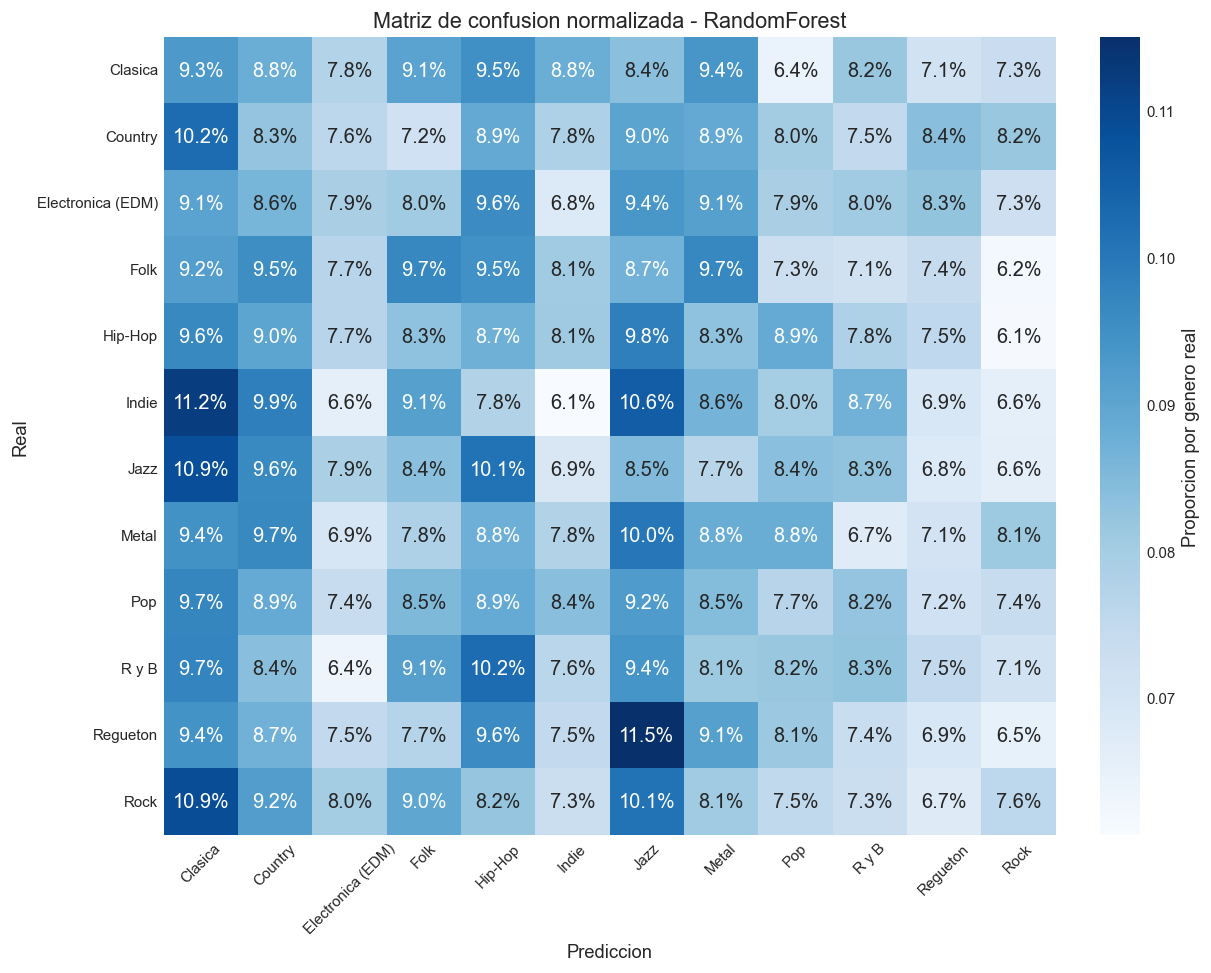

In [49]:
mejor_nombre = resultados_df.iloc[0]['modelo']
mejor_modelo = modelo_logreg if mejor_nombre == 'LogisticRegression' else modelo_rf

pred_mejor = mejor_modelo.predict(X_test)
print(f'Mejor modelo: {mejor_nombre}')
print('Reporte de clasificacion (tabular):')
print(classification_report(y_test, pred_mejor))

labels = sorted(y.unique())
cm = confusion_matrix(y_test, pred_mejor, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
sns.heatmap(
    cm,
    cmap='Blues',
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.1%',
    cbar_kws={'label': 'Proporcion por genero real'},
)
ax.set_title(f'Matriz de confusion normalizada - {mejor_nombre}')
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.show()


## 10. Modelo NLP clasico (TF-IDF + LogisticRegression)


In [50]:
df_nlp = df_limpio.copy()
df_nlp = df_nlp[df_nlp['genero_es'].notna()].copy()

texto_cols = ['track_name', 'artist_name', 'album_name', 'label', 'country']
texto_cols = [c for c in texto_cols if c in df_nlp.columns]

df_nlp['texto'] = (
    df_nlp[texto_cols]
    .astype('string')
    .fillna('')
    .agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

conteo_nlp = df_nlp['genero_es'].astype(str).value_counts()
generos_nlp_validos = conteo_nlp[conteo_nlp >= 30].index
df_nlp = df_nlp[df_nlp['genero_es'].astype(str).isin(generos_nlp_validos)].copy()

X_text = df_nlp['texto']
y_text = df_nlp['genero_es'].astype(str)

Xtr, Xte, ytr, yte = train_test_split(X_text, y_text, test_size=0.2, random_state=42, stratify=y_text)

modelo_nlp = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=70000)),
    ('clf', LogisticRegression(max_iter=1500)),
])

modelo_nlp.fit(Xtr, ytr)
pred_nlp = modelo_nlp.predict(Xte)

print('Accuracy NLP:', round(accuracy_score(yte, pred_nlp), 4))
print('F1 macro NLP:', round(f1_score(yte, pred_nlp, average='macro'), 4))
print('Reporte NLP:')
print(classification_report(yte, pred_nlp))


Accuracy NLP: 0.0831
F1 macro NLP: 0.0831
Reporte NLP:
                   precision    recall  f1-score   support

          Clasica       0.09      0.09      0.09      1432
          Country       0.08      0.08      0.08      1406
Electronica (EDM)       0.08      0.08      0.08      1379
             Folk       0.08      0.08      0.08      1416
          Hip-Hop       0.08      0.09      0.08      1432
            Indie       0.07      0.07      0.07      1401
             Jazz       0.09      0.09      0.09      1435
            Metal       0.09      0.09      0.09      1440
              Pop       0.08      0.08      0.08      1419
            R y B       0.08      0.08      0.08      1417
         Regueton       0.09      0.09      0.09      1400
             Rock       0.08      0.08      0.08      1423

         accuracy                           0.08     17000
        macro avg       0.08      0.08      0.08     17000
     weighted avg       0.08      0.08      0.08     17000

## 11. OpenAI - Resumen y Q&A


In [53]:
dotenv_paths = [
    Path('.env'),
    Path('../.env'),
    Path('/content/.env'),
    Path('/content/drive/MyDrive/.env'),
]
for env_path in dotenv_paths:
    if env_path.exists():
        load_dotenv(env_path, override=False)
        break

api_key = os.getenv('OPENAI_API_KEY')

resumen_modelos = resultados_df.to_dict(orient='records') if 'resultados_df' in globals() else []
contexto = {
    'registros': int(df_limpio.shape[0]),
    'generos_top': df_limpio['genero_es'].astype(str).value_counts().head(8).to_dict(),
    'paises_top': df_limpio['country'].astype(str).value_counts().head(8).to_dict(),
    'labels_top': df_limpio['label'].astype(str).value_counts().head(8).to_dict(),
    'modelos_tabulares': resumen_modelos,
}

if not api_key:
    print('No se detecto OPENAI_API_KEY. Se omite bloque OpenAI.')
else:
    client = OpenAI(api_key=api_key, timeout=30.0, max_retries=4)

    prompt_resumen = f'''
Eres un analista senior de musica y datos.
Genera un resumen ejecutivo en espanol (maximo 12 lineas) a partir de este contexto:
{contexto}
Incluye: calidad de datos, tendencias por genero y conclusiones de modelado.
'''

    try:
        resp = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[
                {'role': 'system', 'content': 'Responde en espanol tecnico y claro.'},
                {'role': 'user', 'content': prompt_resumen},
            ],
            temperature=0.2,
        )
        print('Resumen OpenAI:')
        print(resp.choices[0].message.content)
    except openai.AuthenticationError as e:
        print(f'Error de autenticacion OpenAI: {e}')
    except openai.RateLimitError as e:
        print(f'Rate limit OpenAI: {e}')
    except openai.APIConnectionError as e:
        print(f'Error de conexion OpenAI: {e}')
    except openai.APIStatusError as e:
        print(f'Error de API OpenAI ({e.status_code}): {e}')

    pregunta = 'Que informacion concreta me puedes sacar de los datos?' 
    try:
        resp_qa = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[
                {'role': 'system', 'content': 'Eres un asistente de analitica musical.'},
                {'role': 'user', 'content': f'Contexto: {contexto}\nPregunta: {pregunta}'},
            ],
            temperature=0.2,
        )
        print('Respuesta Q y A OpenAI:')
        print(resp_qa.choices[0].message.content)
    except Exception as e:
        print(f'No se pudo completar Q y A OpenAI: {e}')


Resumen OpenAI:
**Resumen Ejecutivo**

El análisis de 85,000 registros musicales revela una diversidad notable en géneros, con los más destacados siendo Metal (7,200), Jazz (7,177) y Hip-Hop (7,160). Los países que predominan en la producción musical son India (8,629), Canadá (8,620) y Japón (8,582), lo que sugiere un enfoque global en la creación de contenido. Las principales discográficas incluyen a Independent (10,767) y Columbia (10,690), indicando una fuerte presencia de sellos independientes.

La calidad de los datos presenta desafíos, con modelos de machine learning como RandomForest y LogisticRegression mostrando una precisión limitada (8.1% y 8.6%, respectivamente). Las métricas F1 macro también son bajas, lo que sugiere que se requiere una mejora en la calidad de los datos y en la selección de características para optimizar los modelos. En conclusión, aunque existen tendencias claras en géneros y procedencias, es fundamental abordar las limitaciones en la calidad de los datos

## 12. Conclusiones

- Se realizo un AED completo sobre Spotify con enfoque en genero, pais y sello discografico.
- Se aplico visualizacion con buenas practicas de matplotlib (API orientada a objetos).
- Se entrenaron modelos tabulares para clasificar `genre` y se compararon metricas.
- Se construyo un modelo NLP clasico para clasificar genero desde texto de pistas y metadatos.
- Se integro OpenAI para resumen ejecutivo y preguntas en lenguaje natural.
